### IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### LOAD DATASET

In [2]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### DATA UNDERSTANDING

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df.shape

(6607, 20)

In [6]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

                          Missing Count  Missing (%)
Parental_Education_Level             90     1.362192
Teacher_Quality                      78     1.180566
Distance_from_Home                   67     1.014076


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Exam_Score' in num_cols:
    num_cols.remove('Exam_Score')
numerical_cols = df.select_dtypes(include=np.number).columns

In [10]:
def kategorisasi_score(score):
    if score >= 90:
        return 'A (90-100)'
    elif score >= 75:
        return 'B (75-89)'
    elif score >= 60:
        return 'C (60-74)'
    elif score >= 50:
        return 'D (50-59)'
    else:
        return 'E (<50)'

df['Score_Category'] = df['Exam_Score'].apply(kategorisasi_score)
print("\nDistribusi Kategori Exam_Score:")
print(df['Score_Category'].value_counts().sort_index())


Distribusi Kategori Exam_Score:
Score_Category
A (90-100)      22
B (75-89)      102
C (60-74)     6415
D (50-59)       68
Name: count, dtype: int64


### EXPLORATORT DATA ANALYSIS (EDA)

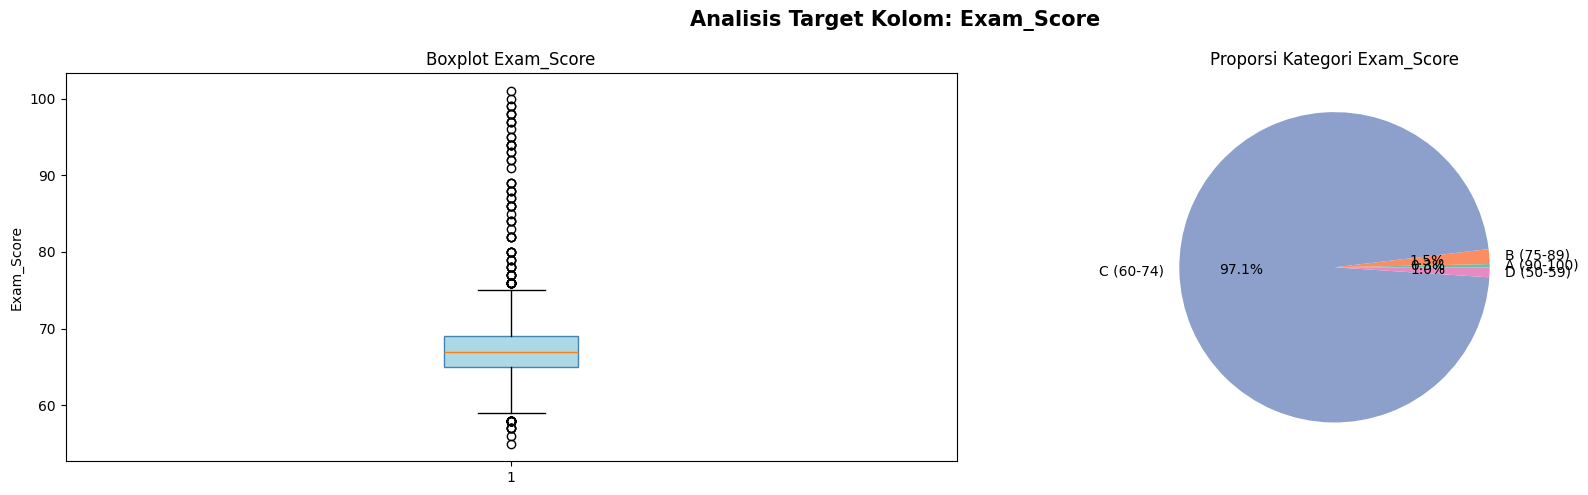

In [11]:
# Analisis Fitur Target
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Boxplot
axes[0].boxplot(df['Exam_Score'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[0].set_title('Boxplot Exam_Score')
axes[0].set_ylabel('Exam_Score')

# Pie chart kategori
kategori_counts = df['Score_Category'].value_counts().sort_index()
axes[1].pie(kategori_counts, labels=kategori_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(kategori_counts)))
axes[1].set_title('Proporsi Kategori Exam_Score')

plt.suptitle('Analisis Target Kolom: Exam_Score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('analisis_exam_score.png', dpi=150)
plt.show()


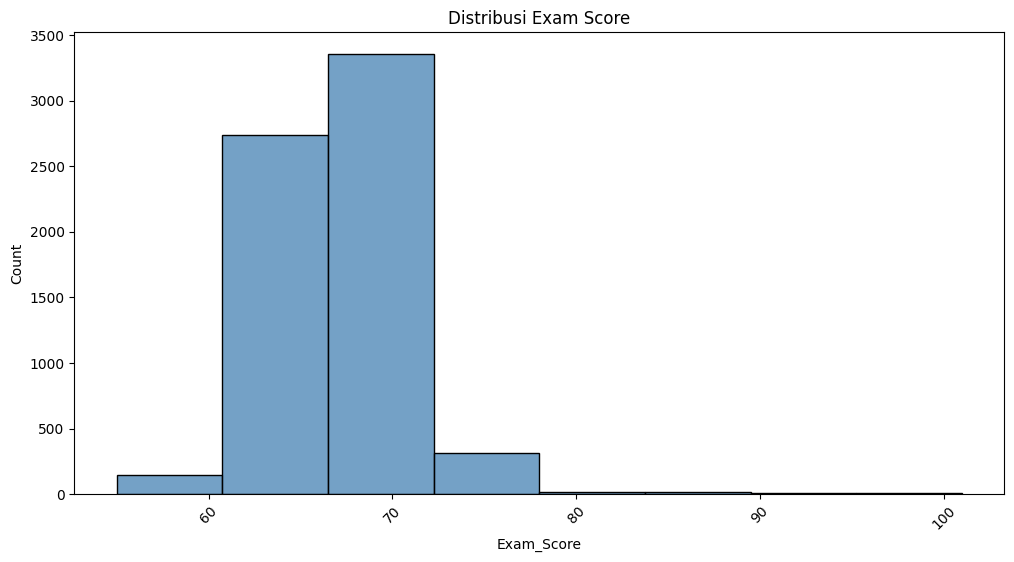

In [12]:
# Visualisasi Distribusi Target
plt.figure(figsize=(12,6))
sns.histplot(df['Exam_Score'],bins=8, color='steelblue',edgecolor='black')
plt.title('Distribusi Exam Score')
plt.xticks(rotation=45)
plt.savefig('distribusi_exam_score.png', dpi=150)
plt.show()


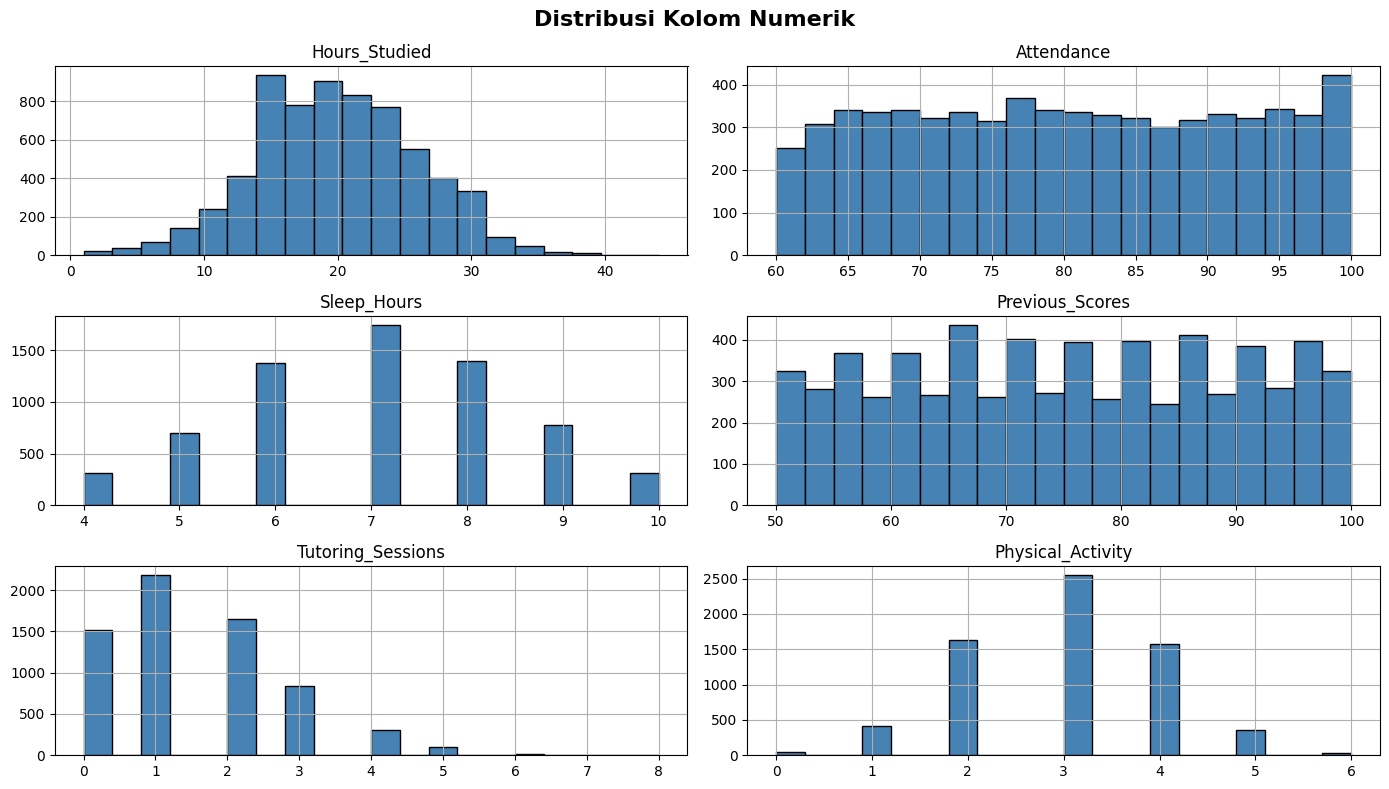

In [13]:
# Distribusi Kolom Numerik
df[num_cols].hist(figsize=(14, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Kolom Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_numerik.png', dpi=150)
plt.show()


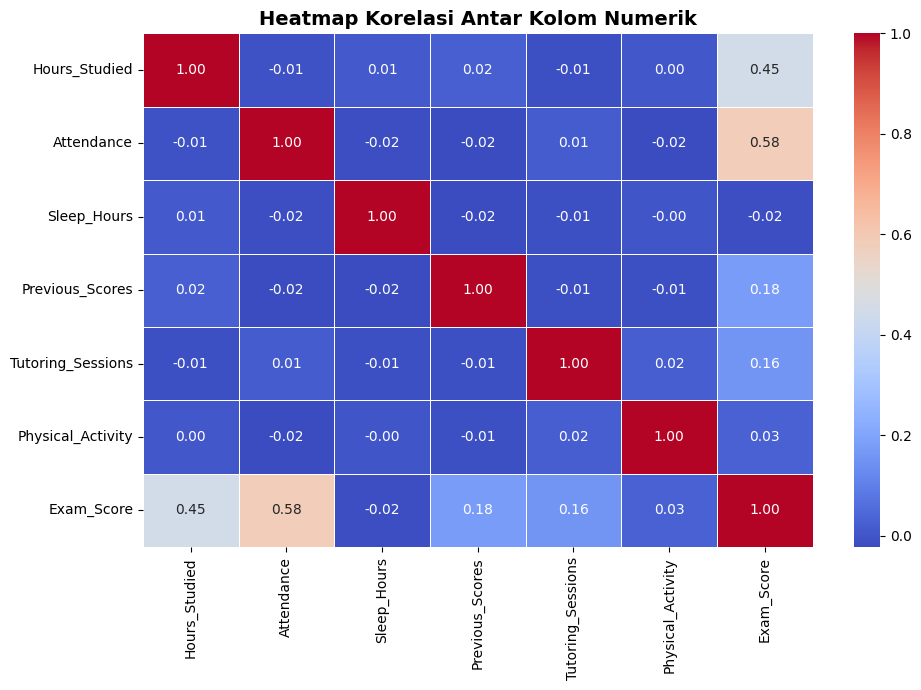

In [14]:
# Correlation Matrix
plt.figure(figsize=(10, 7))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Kolom Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()

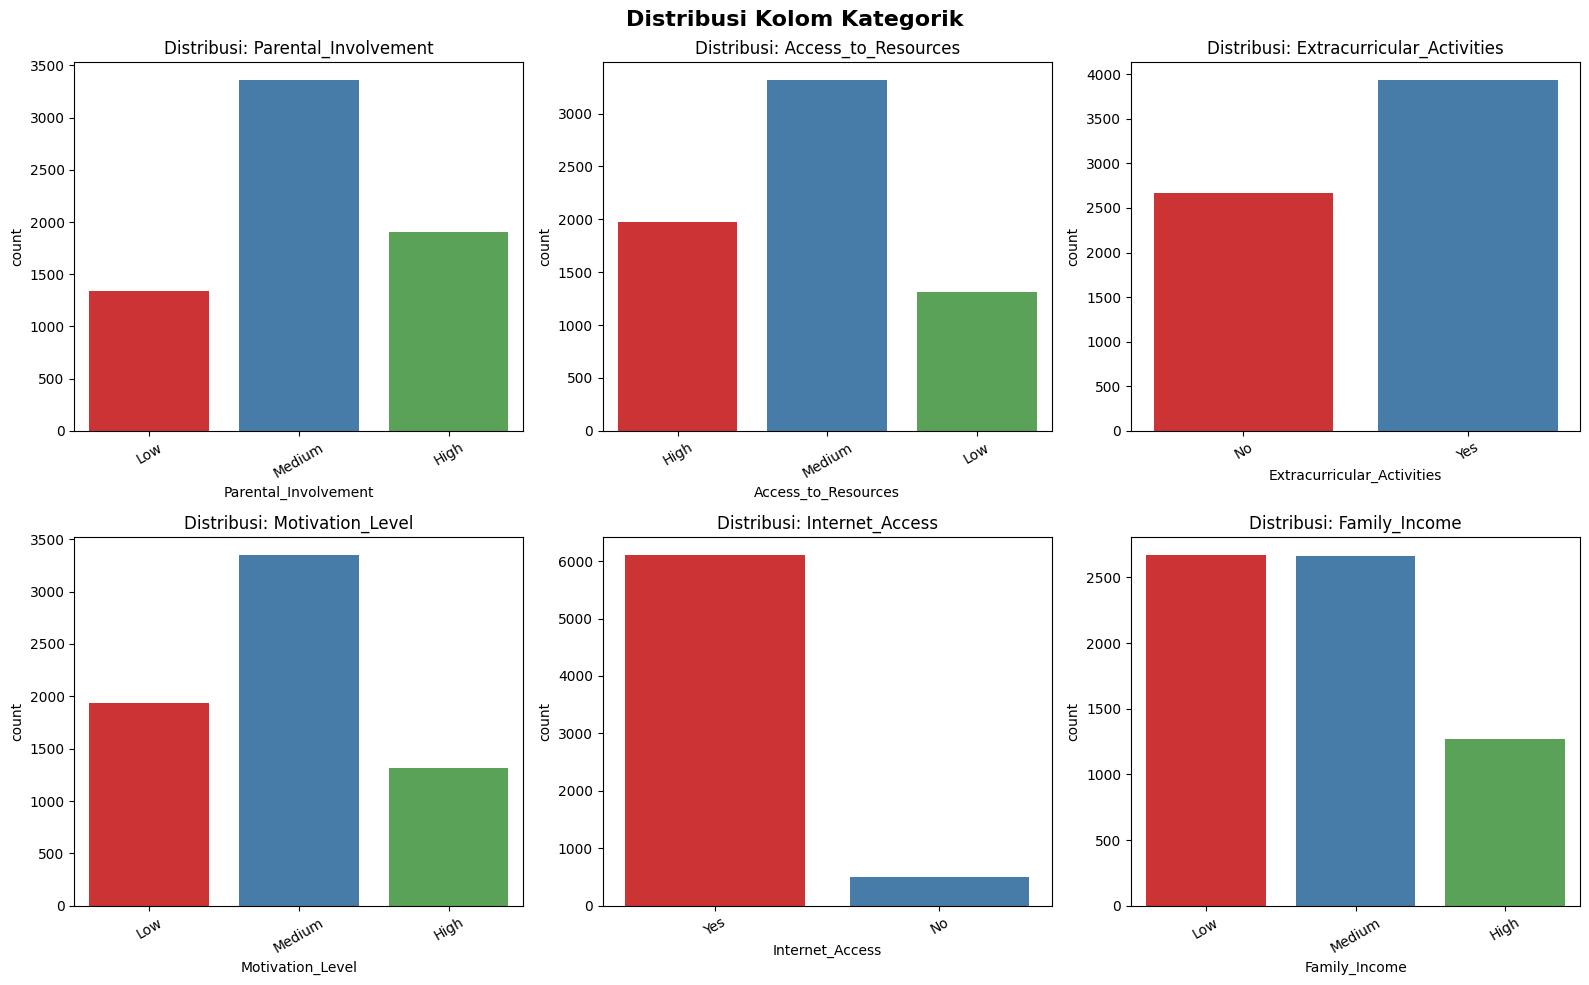

In [15]:
# Distribusi Kolom kategorik
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Kolom Kategorik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_kategorik.png', dpi=150)
plt.show()

### DATA CLEANING

In [16]:
df_clean = df.drop(columns=['Score_Category']).copy()

In [17]:
df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
Score_Category                 0
dtype: int64

In [19]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Score_Category
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,C (60-74)
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,C (60-74)
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,C (60-74)
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,C (60-74)
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,C (60-74)


In [20]:
# Imputasi Missing Values
cols_missing = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_missing:
    jumlah_missing = df_clean[col].isnull().sum()
    modus_val = df_clean[col].mode()[0]
    df_clean[col].fillna(modus_val, inplace=True)

C:\Users\Rafa\AppData\Local\Temp\ipykernel_21620\2532789598.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(modus_val, inplace=True)


In [21]:
df_clean.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [22]:
df.shape

(6607, 21)